# Horn of Africa Rainfall Seasonality

Seasonal cycle of hourly precipitation from ICON and IFS-FESOM
destinE climate projections for 2020 over the Horn of Africa.

**Requires**:
- Polytope auth (see `docs/polytope_setup.md`)
- Conda env `destine` (see `requirements.txt`)

In [4]:
import sys, os
_here = os.getcwd()
if "../get-data" not in sys.path:
    sys.path.insert(0, "../get-data")

import logging, warnings
import earthkit.data
import earthkit.plots
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from polytope_zarr import PolytopeZarrStore

## 1. Fetch data

In [2]:
imerg = xr.open_mfdataset(
    "../../acclimatise/get-data/imerg_africa/yearly_nc/pr_imerg_v07_africa_daily_200*.nc"
    ).sel(lat=slice(5, 10), lon=slice(44, 49))

icon = xr.open_mfdataset(
    "../data/horn_of_africa/ICON/*.nc"
    )
icon["avg_tprate"] = icon.avg_tprate * 86400

ifs = xr.open_mfdataset(
    "../data/horn_of_africa/IFS-FESOM/*.nc"
    )
ifs["avg_tprate"] = ifs.avg_tprate * 86400

## 2. Plot area

/home/dorian.spat/miniconda3/envs/destine/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


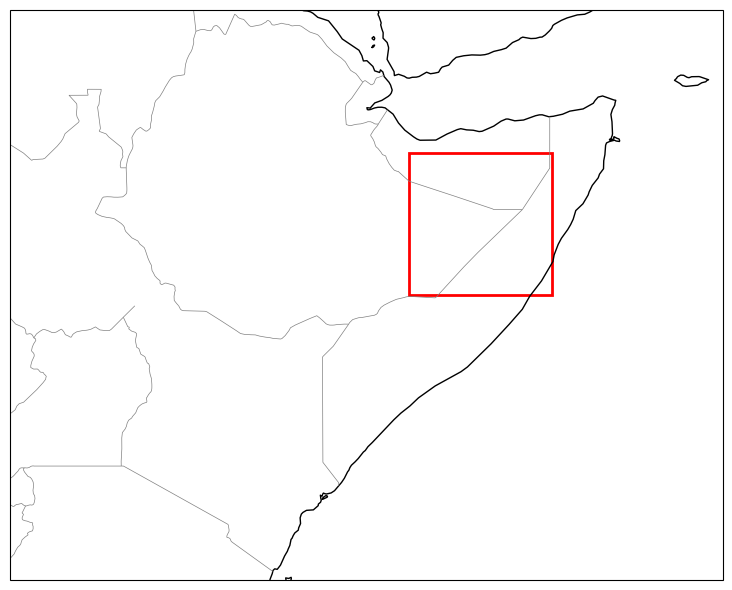

In [9]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# Map extent covering the Greater Horn of Africa
ax.set_extent([30, 55, -5, 15], crs=ccrs.PlateCarree())

# Coastlines and country borders as black lines
ax.coastlines(color="black", lw=1)
ax.add_feature(cfeature.BORDERS, color="grey", lw=0.5)

# Red rectangle marking the 5°×5° analysis region (5–10°N, 44–49°E)
rect = Rectangle((44, 5), 5, 5, linewidth=2, edgecolor="red", facecolor="none",
                 transform=ccrs.PlateCarree())
ax.add_patch(rect)

plt.tight_layout()
plt.savefig("plots/horn_of_africa_region.png", dpi=300)
plt.show()

## 3. Plot seasonal cycle

In [19]:
#calculate daily means
imerg_yd = imerg.mean(dim=["lat", "lon"], skipna=True).groupby("time.dayofyear").mean("time")
icon_yd = icon.mean(dim=["points"], skipna=True).groupby("time.dayofyear").mean("time")
ifs_yd = ifs.mean(dim=["points"], skipna=True).groupby("time.dayofyear").mean("time")

In [20]:
#calculate monthly means
imerg_ym = imerg.mean(dim=["lat", "lon"], skipna=True).groupby("time.month").mean("time")
icon_ym = icon.mean(dim=["points"], skipna=True).groupby("time.month").mean("time")
ifs_ym = ifs.mean(dim=["points"], skipna=True).groupby("time.month").mean("time")

In [21]:
#calculate daily min and max
imerg_ymin = imerg.mean(dim=["lat", "lon"], skipna=True).groupby("time.dayofyear").min("time")
imerg_ymax = imerg.mean(dim=["lat", "lon"], skipna=True).groupby("time.dayofyear").max("time")
icon_ymin = icon.mean(dim=["points"], skipna=True).groupby("time.dayofyear").min("time")
icon_ymax = icon.mean(dim=["points"], skipna=True).groupby("time.dayofyear").max("time")
ifs_ymin = ifs.mean(dim=["points"], skipna=True).groupby("time.dayofyear").min("time")
ifs_ymax = ifs.mean(dim=["points"], skipna=True).groupby("time.dayofyear").max("time")

In [31]:
fsize = 12
plt.rcParams["font.size"] = fsize
fig, axs = plt.subplots(2, 3, figsize = (14, 10), layout = "tight", sharey = 'row')

#daily means
axs[0, 0].plot(imerg_yd.pr, label="IMERG v07", color="black", lw=.8)
axs[0, 0].plot(icon_yd.avg_tprate, label="ICON", color="#29ADE6", ls="--", lw=1)
axs[0, 0].plot(ifs_yd.avg_tprate, label="IFS-FESOM", color="#D158B9", ls="dotted", lw=1)

axs[0, 0].set_xlabel("Day of the year")
axs[0, 0].set_ylabel("Precipitation (mm/day)")
axs[0, 0].spines["top"].set_visible(False)
axs[0, 0].spines["right"].set_visible(False)

#3 day RM
axs[0, 1].plot(imerg_yd.pr.rolling(dayofyear=3, center=True).mean(), label="3 day running mean", color="black", lw=.8)
axs[0, 1].plot(icon_yd.avg_tprate.rolling(dayofyear=3, center=True).mean(), label="", color="#29ADE6", ls="--", lw=1)
axs[0, 1].plot(ifs_yd.avg_tprate.rolling(dayofyear=3, center=True).mean(), label="", color="#D158B9", ls="dotted", lw=1)

axs[0, 1].set_xlabel("Day of the year")
axs[0, 1].spines["top"].set_visible(False)
axs[0, 1].spines["right"].set_visible(False)

axs[0, 1].legend(edgecolor="white")


#monthly means
axs[0, 2].plot(imerg_ym.month, imerg_ym.pr, label="IMERG v07", color="black", lw=.8)
axs[0, 2].plot(icon_ym.month, icon_ym.avg_tprate, label="ICON", color="#29ADE6", ls="--", lw=1)
axs[0, 2].plot(ifs_ym.month, ifs_ym.avg_tprate, label="IFS-FESOM", color="#D158B9", ls="dotted", lw=1)


axs[0, 2].set_xlabel("Month of the year")
axs[0, 2].spines["top"].set_visible(False)
axs[0, 2].spines["right"].set_visible(False)

axs[0, 2].legend(edgecolor="white")

#IMERG range
axs[1, 0].fill_between(imerg_yd.dayofyear, imerg_ymin.pr, imerg_ymax.pr, label="min-max range", color="black", alpha=.2)
axs[1, 0].plot(imerg_yd.pr, color="black", lw=.8)

axs[1, 0].set_xlabel("Day of the year")
axs[1, 0].set_ylabel("Precipitation (mm/day)")

axs[1, 0].spines["top"].set_visible(False)
axs[1, 0].spines["right"].set_visible(False)

axs[1, 0].legend(edgecolor="white")

#ICON range
axs[1, 1].fill_between(icon_yd.dayofyear, icon_ymin.avg_tprate, icon_ymax.avg_tprate, color="#29ADE6", alpha=.2)
axs[1, 1].plot(icon_yd.avg_tprate, label="ICON", color="#29ADE6", lw=.8)

axs[1, 1].set_xlabel("Day of the year")

axs[1, 1].spines["top"].set_visible(False)
axs[1, 1].spines["right"].set_visible(False)


#IFS range
axs[1, 2].fill_between(ifs_yd.dayofyear, ifs_ymin.avg_tprate, ifs_ymax.avg_tprate, color="#D158B9", alpha=.2)
axs[1, 2].plot(ifs_yd.avg_tprate, label="IFS", color="#D158B9", lw=.8)

axs[1, 2].set_xlabel("Day of the year")

axs[1, 2].spines["top"].set_visible(False)
axs[1, 2].spines["right"].set_visible(False)


plt.suptitle("Horn of Africa (2000-2009, lat 5-10°N, lon 44-49°E)")
plt.savefig("plots/seasonality_hornofafrica.png", dpi=300)